# Exercise: Transcription

1. 

## Setup

#### Dependencies

In [1]:
import torch

from torch import Tensor, nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

from matplotlib import pyplot as plt

#### Download data

In [85]:
image_transforms = transforms.ToTensor()

In [86]:
train_dataset = datasets.MNIST(root='G:/My Drive/Arbejde/SDU/Teaching/2024-hedg-summer-school/data', train=True, download=True, transform=image_transforms)
test_dataset = datasets.MNIST(root='G:/My Drive/Arbejde/SDU/Teaching/2024-hedg-summer-school/data', train=False, download=True, transform=image_transforms)

In [87]:
train_data_loader = DataLoader(train_dataset, batch_size=32)
test_data_loader = DataLoader(test_dataset, batch_size=32)

*Let's take a look*

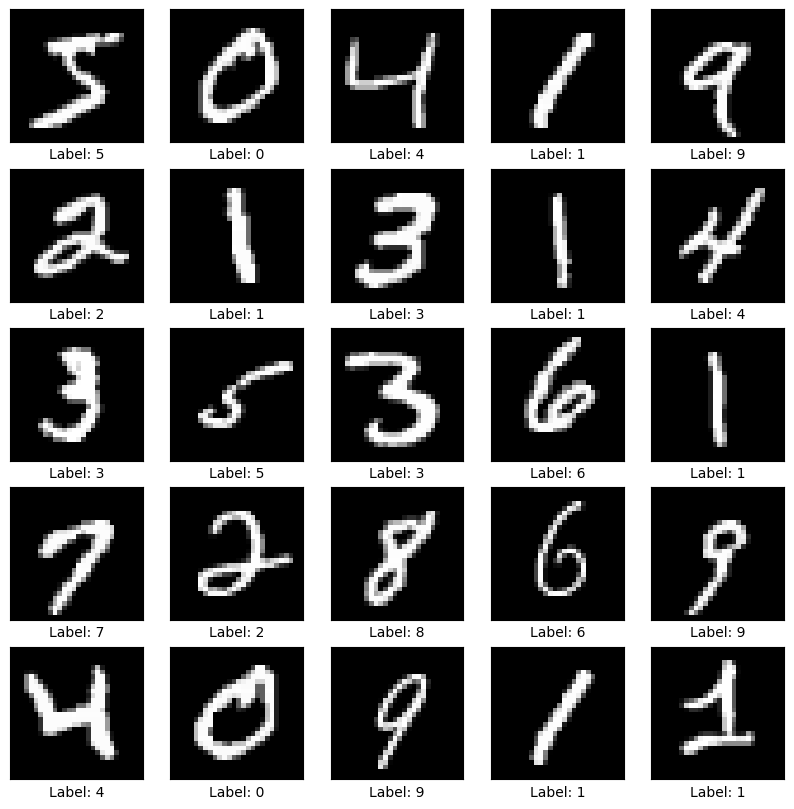

In [93]:
plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_dataset[i][0][0], cmap='gray')
    plt.xlabel(f'Label: {train_dataset[i][1]}')
plt.show()

# **TODO** distribute

In [89]:
class HandwrittenDigitsRecognizer(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.classifier = nn.Linear(800, 10)

    def forward(self, image: Tensor) -> Tensor:
        out = self.conv1(image) # (1, 28, 28) -> (16, 26, 26)
        out = torch.relu(out)
        out = nn.functional.max_pool2d(out, 2) # (16, 26, 26) -> (16, 13, 13)

        out = self.conv2(out) # (16, 13, 13) -> (32, 11, 11)
        out = torch.relu(out)
        out = nn.functional.max_pool2d(out, 2) # (32, 11, 11) -> (32, 5, 5)

        out = torch.flatten(out, 1) # (32, 5, 5) -> (800,)
        out = self.classifier(out) # (800,) -> (10,)

        return out

In [90]:
def train_epoch(model, optimizer, data_loader, loss_fn):
    model.train()

    for image, label in data_loader:
        optimizer.zero_grad()
        
        out = model(image) # make predictions
        loss = loss_fn(out, label) # calculate loss
        loss.backward() # calculate derivatives

        optimizer.step() # update network parameters

In [91]:
@torch.no_grad
def evaluate(model, data_loader):
    model.eval()

    total_correct = 0 # keep count of correct predictions
    total_count = 0 # keep count of total number of predictions

    for image, label in data_loader:
        out = model(image).argmax(1)

        total_correct += (out == label).sum().item()
        total_count += label.size(0)

    return total_correct / total_count # calculate accuracy

In [92]:
model_baseline = HandwrittenDigitsRecognizer()
optimizer_baseline = torch.optim.SGD(model_baseline.parameters(), lr=0.01)

loss_fn = torch.nn.CrossEntropyLoss()

In [94]:
for epoch in range(1, 11):
    train_epoch(model_baseline, optimizer_baseline, train_data_loader, loss_fn)
    acc = evaluate(model_baseline, test_data_loader)

    print(f'Trained for {epoch} epochs. Validation accuracy: {100 * acc}%')

KeyboardInterrupt: 

# Exercise 1

# Exercise 2

# Exercise 3

# Exercise 4